# 1.4 サポートベクターマシン（1/2）分類と回帰

**原典**: scikit-learn User Guide [1.4. Support Vector Machines](https://scikit-learn.org/stable/modules/svm.html) の冒頭〜1.4.3（v1.9.1）

| | |
|---|---|
| **このノートで分かるようになること** | ・「マージン最大化」と「サポートベクター」の意味を、図で説明できる<br>・`SVC` / `NuSVC` / `LinearSVC` の違いと、多クラス分類の仕組み（one-vs-one / one-vs-rest）が分かる<br>・SVM のスコアと確率の違い、確率を出すときの注意点が分かる<br>・不均衡なデータで `class_weight` / `sample_weight` を使える<br>・サポートベクター回帰（SVR）と One-Class SVM の役割が分かる |
| **前提** | [1.1 線形モデル](./01_linear_models_1_ols_regularization.ipynb)（正則化、ロジスティック回帰）、[1.3 カーネルリッジ回帰](./03_kernel_ridge.ipynb)（カーネル、ε-不感損失） |
| **目安時間** | 90〜120 分 |

### 🗺️ 3 行でいうと

1. **SVM** は、2 つのクラスの間に「**できるだけ幅の広い道路**」を通す分類器。道路の端に接する点（**サポートベクター**）だけで境界が決まる。
2. カーネル（1.3 節）を使えば曲がった境界も引け、回帰（**SVR**）や外れ値検出（**One-Class SVM**）にも使える。
3. SVM が出すのは確率ではなく「**スコア**」。確率が必要なら、較正（`CalibratedClassifierCV`）を組み合わせる。

> 📐 **数式について**: 本文は**数式なしで読める**ように書いています（中学修了程度の数学で足ります）。式で確かめたい人は [数式編](./math/04_svm_1_classification_regression_math.md) へ。必要な数学の道具は [数学の準備](../00_math_primer.md)、用語は [用語集](../glossary.md) にまとめています。

### このノートの読み方

| 記号 | 意味 |
|---|---|
| 📖 **ガイドの解説** | 公式ガイドの内容を日本語で説明したもの |
| 💡 **補足** | 初学者向けに、ガイドにない前提知識・直感・たとえ話を足したもの |
| 📚 **用語** / 🔢 **数式を読む** | 初出の用語の説明 /（数式編の中で）数式の記号を 1 つずつ説明し、日本語で読み下したもの |
| 🎯 **なぜ使うのか** / 🏭 **利用例** / 🕰️ **歴史** | 手法が使われる理由・実際の応用・生まれた経緯（参考情報） |
| 🧪 **やってみよう** / 📈 **学習したモデルを見る** / 👀 **結果の読み方** | コードで確かめる / 学習したモデルを図で確かめる / 出力のどこを見ればよいか |
| ⚠️ **つまずきポイント** | 実際に動かして分かった落とし穴（ガイドに書かれていないもの、バージョンによる違いを含む） |
| 🏢 **実務での選ばれ方** | 実際の業務で、その手法が選ばれる場面・選ばれない場面・よく組み合わせる手法 |
| 💬 **ことばで言うと** / 📐 **数式編** | 式の意味を言葉だけで説明したもの / 式・記号の表・導き方をまとめた別ファイルへのリンク |

### 目次

0. 導入: サポートベクターマシンとは（と、マージンの直感）
1. 1.4.1 分類（多クラス分類 / スコアと確率 / 不均衡なデータ）
2. 1.4.2 回帰
3. 1.4.3 密度推定・新規性検出
4. まとめ・確認クイズ

> 続き: [2/2 実践のコツ・カーネル・数式](./04_svm_2_practice_math.ipynb) — 計算量、実践のコツ、カーネル関数、数式（1.4.4〜1.4.8）

## セットアップ

実行済みの出力つきで保存しています。手元で動かす場合は、上から順に実行してください。

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib  # グラフで日本語を表示するため

from sklearn import linear_model as lm

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.precision", 4)
plt.rcParams.update({"figure.figsize": (6, 3.6), "figure.dpi": 80, "axes.grid": True})
rng = np.random.RandomState(0)  # 乱数の種を固定（同じ結果を再現するため）

from sklearn import svm
from sklearn.datasets import make_blobs, make_moons, make_classification, load_iris

def plot_svc(ax, model, X, y, title, margins=True, show_sv=True, levels=None):
    # 2 次元のデータについて、決定関数（decision_function）の等高線を描く
    #   実線 = 決定境界（値 0）、点線 = マージンの境界（値 ±1）
    x0, x1 = X[:, 0], X[:, 1]
    xx, yy = np.meshgrid(np.linspace(x0.min() - 0.5, x0.max() + 0.5, 300),
                         np.linspace(x1.min() - 0.5, x1.max() + 0.5, 300))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.25)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1] if margins else [0], colors="k",
               linestyles=["--", "-", "--"] if margins else ["-"], linewidths=[1, 2, 1] if margins else [2])
    ax.scatter(x0, x1, c=y, cmap="RdBu_r", edgecolor="k", s=20, zorder=2)
    if show_sv and hasattr(model, "support_vectors_") and len(model.support_vectors_):
        sv = model.support_vectors_
        ax.scatter(sv[:, 0], sv[:, 1], s=110, facecolors="none", edgecolors="k", linewidths=1.2, zorder=3)
    ax.set_title(title, fontsize=10); ax.grid(False)

---
## 0. 導入: サポートベクターマシンとは

### 💡 補足: マージン最大化の直感

2 つのクラスを直線で分けるとき、分け方は無数にあります。SVM は、その中から**両側のいちばん近い点までの距離（マージン）が最大になる直線**を選びます。

たとえるなら、2 つのチームの陣地の間に道路を通すとき、「**できるだけ幅の広い道路**」を通すようなものです。道路の中央線が決定境界、道路の両端がマージンの境界です。道路の端に接している家（点）が**サポートベクター**で、道路の位置と幅はこの家だけで決まります。ほかの家をいくら動かしても（道路にかからない限り）道路は変わりません。

幅の広い道路を選んでおけば、新しいデータが少しずれた位置に来ても、正しい側に分類されやすくなります。これが、SVM が未知のデータに強い（汎化性能が高い）理由です。

### 🧪 やってみよう / 📈 学習したモデルを見る: マージン最大の直線

ガイドの例「SVM: Maximum margin separating hyperplane」と同じ考え方で、きれいに分かれる 2 クラスのデータに線形 SVM を当てはめます。比較のため、同じデータを分けられるが「道路」の狭い直線も 2 本描きます。

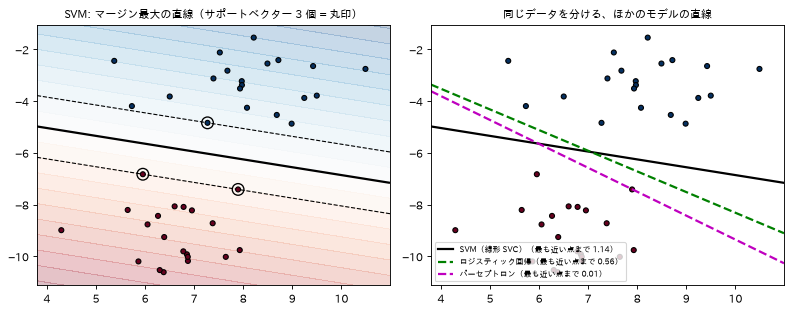

,学習データの正解率,直線から最も近い点までの距離
モデル,,
SVM（線形 SVC）,1.0,1.1413
ロジスティック回帰,1.0,0.5574
パーセプトロン,1.0,0.0058


In [2]:
X0, y0 = make_blobs(n_samples=40, centers=2, random_state=6)
clf0 = svm.SVC(kernel="linear", C=1000).fit(X0, y0)        # C を大きく = ほぼ「はみ出し禁止」（ハードマージン）

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_svc(axes[0], clf0, X0, y0, f"SVM: マージン最大の直線（サポートベクター {len(clf0.support_)} 個 = 丸印）")
w, b = clf0.coef_[0], clf0.intercept_[0]
margin_width = 2 / np.linalg.norm(w)

ax = axes[1]
ax.scatter(X0[:, 0], X0[:, 1], c=y0, cmap="RdBu_r", edgecolor="k", s=20)
t = np.linspace(X0[:, 0].min() - 0.5, X0[:, 0].max() + 0.5, 2)
rows = []
for name, m, style in [("SVM（線形 SVC）", clf0, "k-"),
                       ("ロジスティック回帰", lm.LogisticRegression(C=1000, max_iter=10000).fit(X0, y0), "g--"),
                       ("パーセプトロン", lm.Perceptron(random_state=0).fit(X0, y0), "m--")]:
    wv, bv = m.coef_[0], m.intercept_[0]
    dist = np.abs(X0 @ wv + bv).min() / np.linalg.norm(wv)        # 直線から最も近い点までの距離
    ax.plot(t, -(wv[0] * t + bv) / wv[1], style, lw=2, label=f"{name}（最も近い点まで {dist:.2f}）")
    rows.append({"モデル": name, "学習データの正解率": m.score(X0, y0), "直線から最も近い点までの距離": dist})
ax.set_ylim(axes[0].get_ylim()); ax.set_xlim(axes[0].get_xlim())
ax.legend(fontsize=7, loc="lower left"); ax.set_title("同じデータを分ける、ほかのモデルの直線", fontsize=10); ax.grid(False)
plt.tight_layout(); plt.show()
pd.DataFrame(rows).set_index("モデル")

### 👀 結果の読み方

- 左: 太い実線が SVM の学習した**決定境界**、両側の点線が**マージンの境界**（決定関数の値が ±1 になる線）です。丸印の付いた点が**サポートベクター**で、ちょうど点線の上に乗っています。決定境界は、この 3 つほどの点だけで決まっています。
- 右と表: ロジスティック回帰（緑）とパーセプトロン（ピンク）も、学習データを正しく分けています（正解率 1.0）。しかし、直線から最も近い点までの距離は、SVM の直線がいちばん大きくなっています。つまり SVM は、「正しく分ける直線」の中から**いちばん余裕のある直線**を選んでいるのです。

道路のたとえと図で直感をつかんだところで、ガイドの説明を読みます。

### 📖 ガイドの解説

サポートベクターマシン（SVM）は、**分類**・**回帰**・**外れ値検出**に使われる、教師あり学習の手法の集まりです。

**SVM の利点**

- **高次元の空間**で効果的。
- 次元（特徴の数）がサンプル数より多い場合でも、なお効果的。
- 決定関数の中で学習データの一部（**サポートベクター**と呼ぶ）だけを使うので、メモリ効率も良い。
- 多用途: 決定関数にさまざまな**カーネル関数**を指定できる。よく使われるカーネルは用意されているが、自分で定義したカーネルも使える。

**SVM の欠点**

- 特徴の数がサンプル数よりずっと多い場合、過学習を避けるために、カーネル関数と正則化項の選び方がとても重要になる。
- SVM は**確率の推定値を直接は出さない**。確率は、計算の重い 5 分割交差検証で求める（1.4.1.2 を参照）。

scikit-learn の SVM は、入力として**密な**サンプル（`numpy.ndarray` と、`numpy.asarray` でそれに変換できるもの）と**疎な**サンプル（任意の `scipy.sparse`）の両方に対応しています。ただし、疎なデータで予測するには、疎なデータで学習しておく必要があります。最高の性能を得るには、C 順序の `numpy.ndarray`（密）または `scipy.sparse.csr_matrix`（疎）を、`dtype=float64` で使います。

> 📚 **用語**
> - **教師あり学習**: 正解（ラベルや目的変数）付きのデータから学習する方法。
> - **外れ値検出**: ふつうのデータから外れたデータを見つけること（1.4.3、2.7 節）。
> - **決定関数（decision function）**: 学習したモデルが、入力ごとに計算する「どちらのクラスらしいか」の点数。SVM では、その符号でクラスを決める。
> - **サポートベクター**: 決定境界を決めるのに使われる、学習データの一部の点。境界の近くにある点だけが選ばれる（下の図で確かめます）。
> - **密 / 疎（dense / sparse）**: ほとんどの値が 0 でないデータが密、ほとんどが 0 のデータが疎。文書の単語の出現回数（単語数が数万あるが、1 文書に出るのは一部だけ）は疎の典型。疎なデータは 0 以外の値だけを保存する形式（`scipy.sparse`）で持つと、メモリも計算も節約できる。
> - **C 順序（C-ordered）**: 行列の要素をメモリに「行ごと」に並べる方式。NumPy の既定。SVM の内部の C 言語のライブラリがこの形を前提にしているので、違う形だとコピーが発生する。

### 🎯 なぜ使うのか

- **少ないデータでも汎化しやすい**: マージン最大化という明確な基準があるので、データが少なくても過学習しにくい。
- **カーネルで非線形も扱える**: 1.3 のカーネルトリックを使い、曲線の境界も学習できる。
- **予測が軽い**: 予測に使うのはサポートベクターだけ。

### 🏭 利用例

- **文書分類**: 単語の出現回数のような高次元で疎な特徴の分類で、線形 SVM は長く定番でした（スパム判定、ニュース分類、感情分析）。
- **画像認識**: 深層学習が広まる前は、画像から作った特徴（たとえば歩行者検出の HOG 特徴）を線形 SVM で分類する方法が標準的でした。手書き数字の認識でも高い精度を示しました。
- **生物情報学**: 遺伝子発現データ（特徴数がサンプル数よりずっと多い）による、がんの種類の分類やタンパク質の分類。

### 🕰️ 歴史（参考情報）

- **1963 年**: ソ連の**ヴァプニクとチェルヴォネンキス**が、マージン最大の線形分類器（generalized portrait）を提案しました。
- **1992 年**: **ボーザー、ギヨン、ヴァプニク**が、カーネルトリックと組み合わせた非線形の SVM を発表しました。
- **1995 年**: **コルテスとヴァプニク**が、はみ出しを許す**ソフトマージン**（1.4.7 の $C$ と $\zeta$）を導入し、今日の SVM の形がほぼ完成しました。論文の題名は *Support-Vector Networks* です。
- 1990 年代後半〜2000 年代には、手書き数字認識や文書分類で高い性能を示し、深層学習が広まる 2010 年代前半まで、機械学習の代表的な手法の 1 つでした。
- scikit-learn の SVM は、国立台湾大学の**林智仁（Chih-Jen Lin）**らが開発した **LIBSVM** と **LIBLINEAR** を内部で使っています（1.4.8）。

---
## 1. 分類（1.4.1 Classification）

### 📖 ガイドの解説

`SVC`、`NuSVC`、`LinearSVC` は、2 値分類と多クラス分類ができるクラスです。

- `SVC` と `NuSVC` はよく似た方法ですが、受け付ける引数が少し違い、数式上の定式化も違います（1.4.7 を参照）。
- `LinearSVC` は、**線形カーネルの場合に特化した、より速い**サポートベクター分類の実装です。`SVC` や `NuSVC` が持つ属性の一部（`support_` など）を持ちません。`LinearSVC` は損失関数に `squared_hinge` を使い、liblinear による実装のため、**切片も正則化**します（切片を使う場合）。この影響は、`intercept_scaling` 引数を慎重に調整すれば小さくできます。この引数を使うと、切片の項に、ほかの特徴とは違う正則化の効き方をさせられます。そのため、分類結果やスコアが、ほかの 2 つの分類器とは違うことがあります。

ほかの分類器と同じく、`SVC`、`NuSVC`、`LinearSVC` は 2 つの配列を入力にとります。学習サンプルを持つ形 `(n_samples, n_features)` の配列 `X` と、クラスラベル（文字列または整数）を持つ形 `(n_samples,)` の配列 `y` です。

> 📚 **用語**
> - **squared_hinge（二乗ヒンジ損失）**: ヒンジ損失 $\max(0, 1 - y f(x))$ を二乗したもの。マージンの内側に入った分を二乗で罰する。`SVC` は二乗しないヒンジ損失を使う（2/2 の 1.4.7 で比べます）。
> - **切片の正則化**: 係数だけでなく、切片 $b$ にも「小さくしろ」という罰をかけてしまうこと。データが原点から遠いと、境界がずれる原因になる（2/2 で実験します）。

### 🧪 やってみよう: ガイドのコード例

In [3]:
X = [[0, 0], [1, 1]]
y = [0, 1]
clf = svm.SVC()
clf.fit(X, y)
print("predict([[2., 2.]]) =", clf.predict([[2., 2.]]))
assert (clf.predict([[2., 2.]]) == [1]).all()                 # ガイドの出力と一致

print("support_vectors_ =", clf.support_vectors_.tolist())    # サポートベクターそのもの
print("support_         =", clf.support_)                       # 学習データの中での番号
print("n_support_       =", clf.n_support_)                     # クラスごとのサポートベクターの数
assert clf.support_vectors_.tolist() == [[0.0, 0.0], [1.0, 1.0]] and list(clf.n_support_) == [1, 1]

predict([[2., 2.]]) = [1]
support_vectors_ = [[0.0, 0.0], [1.0, 1.0]]
support_         = [0 1]
n_support_       = [1 1]


📖 SVM の決定関数（1.4.7 で詳しく扱います）は、**サポートベクター**と呼ばれる学習データの一部だけに依存します。サポートベクターの情報は、属性 `support_vectors_`（サポートベクター自身）、`support_`（その番号）、`n_support_`（クラスごとの数）で確かめられます。

👀 学習データが 2 点しかないので、2 点とも**サポートベクター**になっています。

#### 📈 学習したモデルを見る: 3 つの分類器の境界

`make_moons`（2 つの三日月が組み合わさった、直線では分けられないデータ）で、`LinearSVC`、線形カーネルの `SVC`、RBF カーネルの `SVC` が学習した境界を並べます。

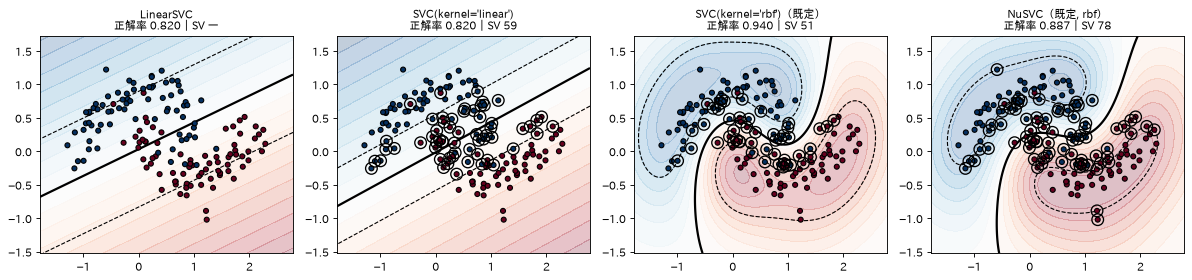

LinearSVC に support_ はあるか: False


In [4]:
Xm, ym = make_moons(n_samples=150, noise=0.2, random_state=0)
models_m = [("LinearSVC", svm.LinearSVC(C=1.0)), ("SVC(kernel='linear')", svm.SVC(kernel="linear", C=1.0)),
            ("SVC(kernel='rbf')（既定）", svm.SVC(C=1.0)), ("NuSVC（既定, rbf）", svm.NuSVC())]
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (name, m) in zip(axes, models_m):
    m.fit(Xm, ym)
    n_sv = len(m.support_) if hasattr(m, "support_") else "—"
    plot_svc(ax, m, Xm, ym, f"{name}\n正解率 {m.score(Xm, ym):.3f}｜SV {n_sv}")
plt.tight_layout(); plt.show()
print("LinearSVC に support_ はあるか:", hasattr(models_m[0][1], "support_"))

### 👀 結果の読み方

- `LinearSVC` と `SVC(kernel='linear')` は、どちらも**直線**の境界です。損失関数（二乗ヒンジ / ヒンジ）と切片の扱いが違うので、直線の位置は少し違います。
- 既定の `SVC`（RBF カーネル）と `NuSVC` は、三日月の形に沿った**曲線**の境界を学習しています。
- 丸印がサポートベクターです。境界の近く（点線の間）や、反対側にはみ出した点が選ばれています。`LinearSVC` は、ガイドのとおり `support_` 属性を持たないので丸印がありません。

### 1.4.1.1 多クラス分類

📖 `SVC` と `NuSVC` は、多クラス分類に **one-versus-one（ovo, 一対一）** 方式を使います。この方式では、`n_classes * (n_classes - 1) / 2` 個の分類器を作り、それぞれを 2 クラスだけのデータで学習します。内部のソルバは、学習には常にこの ovo 方式を使います。ただし既定では、`decision_function_shape` 引数が `"ovr"`（one-vs-rest, 一対他）になっています。これは、ほかの分類器とインターフェースをそろえるために、ovo の決定関数を単調な変換で、形 `(n_samples, n_classes)` の ovr の決定関数に変換するものです。

> 📚 **用語**
> - **one-versus-one（ovo）**: すべての 2 クラスの組について分類器を作り、多数決で決める方法。4 クラスなら 6 組（0 対 1、0 対 2、…、2 対 3）。
> - **one-versus-rest（ovr）**: クラスごとに「そのクラスか、それ以外か」の分類器を作る方法。4 クラスなら 4 個。
> - **単調な変換**: 大小関係を変えない変換。順位は保たれる。

### 💬 分類器の数

**ことばで言うと**: クラスの中から 2 つを選ぶ組み合わせの数（クラス数 ×（クラス数 − 1）÷ 2）。3 クラスなら 3 個、4 クラスなら 6 個、10 クラスなら 45 個。クラス数の二乗に近い速さで増えるが、1 つ 1 つの分類器は 2 クラス分のデータしか使わないので軽い。

In [5]:
X = [[0], [1], [2], [3]]
Y = [0, 1, 2, 3]
clf = svm.SVC(decision_function_shape='ovo')
clf.fit(X, Y)
dec = clf.decision_function([[1]])
print("ovo の決定関数の列数:", dec.shape[1], "（4 クラス → 4*3/2 = 6）")
assert dec.shape[1] == 6
clf.decision_function_shape = "ovr"
dec = clf.decision_function([[1]])
print("ovr に変えた決定関数の列数:", dec.shape[1])
assert dec.shape[1] == 4

ovo の決定関数の列数: 6 （4 クラス → 4*3/2 = 6）
ovr に変えた決定関数の列数: 4


📖 一方、`LinearSVC` は **one-vs-rest** の多クラス方式を実装しているので、`n_classes` 個のモデルを学習します。

In [6]:
lin_clf = svm.LinearSVC()
lin_clf.fit(X, Y)
dec = lin_clf.decision_function([[1]])
print("LinearSVC の決定関数の列数:", dec.shape[1])
assert dec.shape[1] == 4

LinearSVC の決定関数の列数: 4


#### 📖 多クラス方式の詳細（Details on multi-class strategies）

`LinearSVC` は、別の多クラス方式として、Crammer と Singer が定式化した、いわゆる**多クラス SVM** も実装しています（`multi_class='crammer_singer'`）。実際には、結果がほとんど同じで計算時間がずっと短いので、通常は one-vs-rest のほうが好まれます。

**属性の形**

- one-vs-rest の `LinearSVC`: `coef_` は `(n_classes, n_features)`、`intercept_` は `(n_classes,)`。係数の各行が、`n_classes` 個の one-vs-rest 分類器の 1 つに対応し、順番は「one」のクラスの順。
- one-vs-one の `SVC` / `NuSVC`（線形カーネルの場合）: `coef_` は `(n_classes * (n_classes - 1) / 2, n_features)`、`intercept_` は `(n_classes * (n_classes - 1) / 2,)`。各行が 1 つの 2 値分類器に対応し、クラス 0〜n の順番は「0 対 1」「0 対 2」…「0 対 n」「1 対 2」「1 対 3」…「n−1 対 n」。
- `dual_coef_` の形は `(n_classes - 1, n_SV)` で、並び方は少し分かりにくいものです（各サポートベクターについて、「自分のクラス」と「ほかのクラス」を比べる分類器ごとの発言力が並ぶ）。詳しい並び方の表は数式編にあります。

> 📐 式で確かめたい人へ: [数式編「多クラスの `dual_coef_` の並び方」](./math/04_svm_1_classification_regression_math.md#dualcoef)

### 🧪 やってみよう: アヤメ（3 クラス）で属性の形を確かめる

In [7]:
iris = load_iris()
Xi, yi = iris.data, iris.target
s_lin = svm.SVC(kernel="linear").fit(Xi, yi)
l_lin = svm.LinearSVC(max_iter=10000).fit(Xi, yi)
cs = svm.LinearSVC(multi_class="crammer_singer", max_iter=10000).fit(Xi, yi)
pd.DataFrame({
    "coef_": [s_lin.coef_.shape, l_lin.coef_.shape, cs.coef_.shape],
    "intercept_": [s_lin.intercept_.shape, l_lin.intercept_.shape, cs.intercept_.shape],
    "dual_coef_": [s_lin.dual_coef_.shape, "—", "—"],
    "学習データの正解率": [s_lin.score(Xi, yi), l_lin.score(Xi, yi), cs.score(Xi, yi)],
}, index=["SVC(kernel='linear')（ovo）", "LinearSVC（ovr）", "LinearSVC（crammer_singer）"])

/home/user/sandbox/study-sklearn/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:1295: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,coef_,intercept_,dual_coef_,学習データの正解率
SVC(kernel='linear')（ovo）,"(3, 4)","(3,)","(2, 27)",0.9933
LinearSVC（ovr）,"(3, 4)","(3,)",—,0.9667
LinearSVC（crammer_singer）,"(3, 4)","(3,)",—,0.9800


👀 3 クラスなので、ovo も ovr も分類器は 3 個（3×2/2 = 3）で、`coef_` はどちらも 3 行です。ただし行の意味が違います（ovo は「0 対 1」「0 対 2」「1 対 2」、ovr は「0 対 他」「1 対 他」「2 対 他」）。`dual_coef_` は `(3 − 1, サポートベクターの数)` の形です。Crammer–Singer 方式も、正解率は one-vs-rest とほぼ同じでした。

#### 📈 学習したモデルを見る: アヤメの決定領域

ガイドの例「Plot different SVM classifiers in the iris dataset」と同じく、**がく片**の長さと幅の 2 特徴だけを使って、4 種類の SVM が学習した領域を並べます。

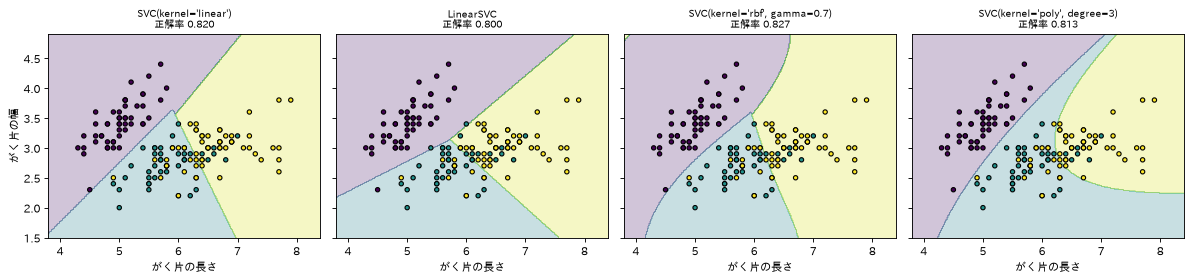

In [8]:
X2 = Xi[:, :2]                                       # がく片の長さ、がく片の幅
models_i = [("SVC(kernel='linear')", svm.SVC(kernel="linear", C=1.0)),
            ("LinearSVC", svm.LinearSVC(C=1.0, max_iter=10000)),
            ("SVC(kernel='rbf', gamma=0.7)", svm.SVC(kernel="rbf", gamma=0.7, C=1.0)),
            ("SVC(kernel='poly', degree=3)", svm.SVC(kernel="poly", degree=3, gamma="auto", C=1.0))]
xx, yy = np.meshgrid(np.linspace(X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5, 300),
                     np.linspace(X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5, 300))
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, (name, m) in zip(axes, models_i):
    m.fit(X2, yi)
    ax.contourf(xx, yy, m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape), alpha=0.25, cmap="viridis")
    ax.scatter(X2[:, 0], X2[:, 1], c=yi, cmap="viridis", edgecolor="k", s=15)
    ax.set_title(f"{name}\n正解率 {m.score(X2, yi):.3f}", fontsize=9); ax.set_xlabel("がく片の長さ"); ax.grid(False)
axes[0].set_ylabel("がく片の幅"); plt.tight_layout(); plt.show()

👀 線形の 2 つ（左 2 枚）は直線で領域を分け、RBF と多項式のカーネル（右 2 枚）は曲線で分けています。左の 2 枚は同じ「線形」でも、ovo（`SVC`）と ovr（`LinearSVC`）、損失関数と切片の扱いの違いから、境界の位置が少し違います。がく片だけでは versicolor（緑）と virginica（黄）が大きく重なっていて、どのモデルでも完全には分けられません。

### 1.4.1.2 スコアと確率

📖 `SVC` と `NuSVC` の `decision_function` メソッドは、サンプルごと・クラスごとの**スコア**を返します（2 値の場合はサンプルごとに 1 つ）。コンストラクタの `probability` を `True` にすると、クラスに属する**確率**の推定値（`predict_proba` と `predict_log_proba`）が使えるようになります。2 値の場合、確率は **Platt スケーリング**で較正されます。これは、SVM のスコアに対してロジスティック回帰を当てはめるもので、学習データ上での追加の交差検証で学習します。多クラスの場合は、Wu・Lin・Weng（2004）の方法で拡張されます。

> 📖 **ノート**: 同じ確率の較正の手順は、`CalibratedClassifierCV`（1.16 節）ですべての推定器に使えます。`SVC` と `NuSVC` の場合、この手順は内部の libsvm に組み込まれているので、scikit-learn の `CalibratedClassifierCV` には依存しません。

Platt スケーリングに含まれる交差検証は、大きなデータでは重い処理です。さらに、確率の推定値はスコアと**食い違う**ことがあります。

- スコアの argmax（最大のクラス）が、確率の argmax と一致しないことがある。
- 2 値分類で、`predict_proba` の出力が 0.5 未満なのに、`predict` で正例と判定されることがある（その逆も）。

Platt の方法には、理論的な問題があることも知られています。確信度のスコアが必要でも、それが確率である必要がないなら、`probability=False` にして、`predict_proba` の代わりに `decision_function` を使うことが勧められています。

`decision_function_shape='ovr'` かつ `n_classes > 2` のとき、`decision_function` と違って、`predict` は既定では**同点を解消しません**。`break_ties=True` にすると、`predict` の出力が `np.argmax(clf.decision_function(...), axis=1)` と同じになります。そうしないと、同点のクラスのうち最初のクラスが常に返されます。ただし、計算コストがかかります。

> 📚 **用語**
> - **スコア / 確率**: スコアは「どちらにどれだけ寄っているか」の点数で、範囲に決まりはない。確率は 0〜1 で、全クラスの合計が 1。
> - **較正（calibration）**: スコアや予測確率を、「0.8 と言ったら本当に 8 割当たる」ような、意味のある確率に合わせ直すこと（1.16 節）。
> - **Platt スケーリング**: SVM のスコアを、シグモイド関数（S 字の曲線、1.1 の 3/4）で確率に変換する方法。S 字の傾きと位置を、交差検証で得たスコアと正解から、ロジスティック回帰で学習する。
> - **同点（tie）**: 複数のクラスのスコアや票数が同じになること。ovo の多数決では票数の同点がよく起きる。

💬 **ことばで言うと**: SVM のスコアを S 字の曲線に通して確率にする。S 字の形は、「スコアがいくつのとき、実際に何割が正例だったか」をデータから学んで決める。

> 📐 式で確かめたい人へ: [数式編「Platt スケーリング」](./math/04_svm_1_classification_regression_math.md#platt)

### ⚠️ つまずきポイント（バージョンによる違い）: `probability=True` は非推奨

scikit-learn **1.9** で、`SVC` / `NuSVC` の `probability` 引数は**非推奨**になり、1.11 で削除される予定です。ガイドの本文（v1.9.1）はまだ `probability=True` で説明していますが、実際に使うと次の警告が出ます。代わりに、ノートで触れられている `CalibratedClassifierCV(SVC(), ensemble=False)` を使うよう案内されます。

In [9]:
Xb, yb = make_classification(n_samples=300, n_features=5, flip_y=0.2, random_state=0)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    old = svm.SVC(probability=True, random_state=0).fit(Xb, yb)
for w in caught:
    if w.category is FutureWarning:
        print("FutureWarning:", str(w.message))

### 🧪 やってみよう: スコア・確率・予測の食い違い

旧来の `probability=True` と、新しい書き方の `CalibratedClassifierCV(SVC(), ensemble=False)` で、「`predict` の結果」と「確率が 0.5 を超えるか」が一致するかを数えます。ノイズの多い 2 値データを使います。

In [10]:
from sklearn.calibration import CalibratedClassifierCV

base = svm.SVC().fit(Xb, yb)                                           # 確率なしの SVC
cal = CalibratedClassifierCV(svm.SVC(), ensemble=False).fit(Xb, yb)    # 新しい書き方

old_proba = old.predict_proba(Xb)[:, 1]
cal_proba = cal.predict_proba(Xb)[:, 1]
pd.DataFrame({
    "predict と「確率 > 0.5」が食い違う数": [((old.predict(Xb) == 1) != (old_proba > 0.5)).sum(),
                                            ((cal.predict(Xb) == 1) != (cal_proba > 0.5)).sum()],
    "素の SVC の predict と食い違う数": [(old.predict(Xb) != base.predict(Xb)).sum(),
                                    (cal.predict(Xb) != base.predict(Xb)).sum()],
}, index=["SVC(probability=True)（非推奨）", "CalibratedClassifierCV(SVC(), ensemble=False)"])

,predict と「確率 > 0.5」が食い違う数,素の SVC の predict と食い違う数
SVC(probability=True)（非推奨）,2,0
"CalibratedClassifierCV(SVC(), ensemble=False)",0,1


👀 旧来の `probability=True` では、`predict` が正例と判定したのに確率が 0.5 未満、というガイドの言う食い違いが実際に起きています。`predict` は決定関数の符号で決まり、確率は別に学習した Platt スケーリングで決まるからです。

`CalibratedClassifierCV` の `predict` は「確率が最大のクラス」を返すので、確率との食い違いは 0 です。その代わり、素の `SVC` の `predict`（決定関数の符号）とは食い違うことがあります。**どの値を判定の基準にしているか**が違うので、どちらかとは必ず食い違いうる、ということです。

#### 📈 学習したモデルを見る: スコアから確率への変換

`CalibratedClassifierCV` が学習した、決定関数の値（スコア）から確率への変換を描きます。

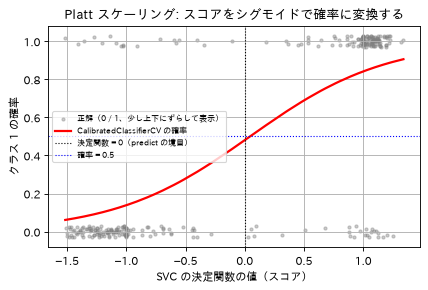

In [11]:
scores = base.decision_function(Xb)
order = np.argsort(scores)
plt.scatter(scores, yb + np.random.RandomState(0).uniform(-0.03, 0.03, len(yb)), s=8, alpha=0.4, c="gray",
            label="正解（0 / 1、少し上下にずらして表示）")
plt.plot(scores[order], cal_proba[order], "r-", lw=2, label="CalibratedClassifierCV の確率")
plt.axvline(0, color="k", ls=":", lw=1, label="決定関数 = 0（predict の境目）")
plt.axhline(0.5, color="b", ls=":", lw=1, label="確率 = 0.5")
plt.xlabel("SVC の決定関数の値（スコア）"); plt.ylabel("クラス 1 の確率")
plt.legend(fontsize=7); plt.title("Platt スケーリング: スコアをシグモイドで確率に変換する"); plt.show()

👀 赤い S 字が、学習したスコア→確率の変換です。スコアが大きいほど確率が 1 に近づきます。確率が 0.5 になる位置（赤い線と青の点線の交点）は、スコア 0（黒の点線）と**ほぼ同じですが、ぴったりではありません**。S 字の位置（Platt スケーリングで学習する切片）が、ちょうどスコア 0 になるとは限らないからです。このわずかなずれの間に入ったサンプルで、`predict`（スコアの符号）と確率の判定が食い違います。このデータではずれが小さいので食い違いは 1 点だけでしたが、データによってはもっと大きくずれます。

💡 また、S 字は 0 や 1 に張り付かず、スコアが大きくても確率は 0.9 程度にとどまっています。ノイズの多いデータ（`flip_y=0.2` で 2 割のラベルを入れ替えた）なので、「スコアが大きくても 1 割くらいは外れる」ことを、確率がきちんと反映しています。

### 🧪 やってみよう: `break_ties` の効果

3 クラスのデータで、平面上の各点について「`predict` の結果」と「`decision_function` の最大のクラス」が食い違う点を数え、図に描きます。

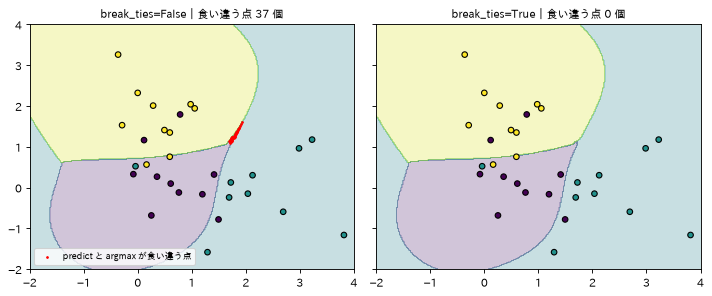

In [12]:
X3, y3 = make_blobs(n_samples=30, centers=[[0, 0], [2, 0], [1, 1.7]], cluster_std=0.8, random_state=0)
xx, yy = np.meshgrid(np.linspace(-2, 4, 300), np.linspace(-2, 4, 300))
G = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, bt in zip(axes, [False, True]):
    c = svm.SVC(break_ties=bt).fit(X3, y3)
    diff = c.predict(G) != c.decision_function(G).argmax(axis=1)
    ax.contourf(xx, yy, c.predict(G).reshape(xx.shape), alpha=0.25, cmap="viridis")
    ax.scatter(G[diff, 0], G[diff, 1], s=2, c="red", label="predict と argmax が食い違う点")
    ax.scatter(X3[:, 0], X3[:, 1], c=y3, cmap="viridis", edgecolor="k", s=25)
    ax.set_title(f"break_ties={bt}｜食い違う点 {diff.sum()} 個", fontsize=10); ax.grid(False)
axes[0].legend(fontsize=8, loc="lower left"); plt.tight_layout(); plt.show()

👀 `break_ties=False`（既定）では、黄と青緑の領域の境目の一部（赤い線のように見える部分）で、`predict` と `decision_function` の最大のクラスが食い違っています。ここは、ovo の 3 つの分類器の多数決が「1 票ずつ」の同点になる場所です。`predict` は同点のとき、同点のクラスのうち最初のクラスを返しますが、`decision_function` は連続的なスコアで差をつけるので、結果が分かれます。`break_ties=True` にすると、`predict` も `decision_function` で同点を解消するので、食い違いがなくなります。

### 1.4.1.3 不均衡な問題

📖 特定のクラスや特定のサンプルを重視したい問題では、`class_weight` と `sample_weight` 引数が使えます。

- `SVC`（`NuSVC` は除く）は、`class_weight` を実装しています。`{クラスラベル: 値}` の形の辞書で、値は 0 より大きい浮動小数点数です。クラス `class_label` の `C` を `C * value` にします。
- `SVC`、`NuSVC`、`SVR`、`NuSVR`、`LinearSVC`、`LinearSVR`、`OneClassSVM` は、`fit` メソッドの `sample_weight` 引数で、サンプルごとの重みにも対応しています。`class_weight` と同じく、$i$ 番目のサンプルの `C` を `C * sample_weight[i]` にします。これにより、分類器はそのサンプルを正しく分類しようとします。

> 📚 **用語**
> - **不均衡なデータ（imbalanced data）**: クラスごとのサンプル数に大きな差があるデータ。例: 不正取引は全取引の 0.1% しかない。何もしないと、モデルは多数派のクラスばかり当てるようになりがち。
> - **`class_weight="balanced"`**: クラスの重みを、サンプル数に反比例するように自動で決める設定（2/2 の 1.4.5 で触れます）。

💡 **`C` を大きくする = そのサンプルのはみ出しを重く罰する**。少数派のクラスの `C` を大きくすると、「少数派を間違えるくらいなら、多数派を少し間違えてもよい」という境界になります。

### 🧪 やってみよう / 📈 学習したモデルを見る: ガイドの図「不均衡なクラス」

ガイドの例「SVM: Separating hyperplane for unbalanced classes」と同じく、1000 点と 100 点の 2 クラスで、重みなし・重みありの線形 SVM が学習した境界を比べます。

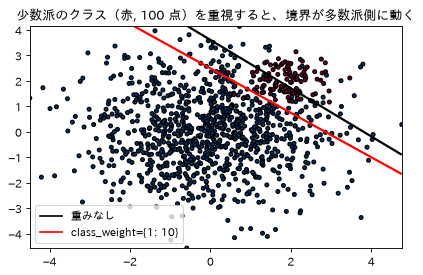

,少数派（クラス 1）の再現率,多数派（クラス 0）の再現率,全体の正解率
重みなし,0.59,0.976,0.9409
class_weight={1: 10},0.97,0.904,0.9100


In [13]:
Xu, yu = make_blobs(n_samples=[1000, 100], centers=[[0.0, 0.0], [2.0, 2.0]], cluster_std=[1.5, 0.5],
                    random_state=0, shuffle=False)
plain = svm.SVC(kernel="linear", C=1.0).fit(Xu, yu)
weighted = svm.SVC(kernel="linear", C=1.0, class_weight={1: 10}).fit(Xu, yu)

xx, yy = np.meshgrid(np.linspace(Xu[:, 0].min(), Xu[:, 0].max(), 200), np.linspace(Xu[:, 1].min(), Xu[:, 1].max(), 200))
plt.scatter(Xu[:, 0], Xu[:, 1], c=yu, cmap="RdBu_r", edgecolor="k", s=12)
for m, color, name in [(plain, "k", "重みなし"), (weighted, "r", "class_weight={1: 10}")]:
    plt.contour(xx, yy, m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape),
                levels=[0], colors=color, linewidths=2)
    plt.plot([], [], color=color, label=name)
plt.legend(); plt.grid(False); plt.title("少数派のクラス（赤, 100 点）を重視すると、境界が多数派側に動く"); plt.show()

from sklearn.metrics import recall_score
pd.DataFrame({name: {"少数派（クラス 1）の再現率": recall_score(yu, m.predict(Xu)),
                     "多数派（クラス 0）の再現率": recall_score(yu, m.predict(Xu), pos_label=0),
                     "全体の正解率": m.score(Xu, yu)} for name, m in [("重みなし", plain), ("class_weight={1: 10}", weighted)]}).T

> 📚 **用語**: **再現率（recall）** — 本当にそのクラスであるサンプルのうち、正しくそのクラスと判定できた割合（3.4 節）。

### 👀 結果の読み方

- 重みなし（黒）の境界は少数派（赤）の集まりに食い込んでいて、少数派の一部を見逃しています。
- 少数派のクラスの `C` を 10 倍にした赤い境界は、多数派の側に押し出され、少数派をほぼすべて捉えています。その代わり、境界の近くにある多数派の点を少数派と誤判定する数が増えます。
- 表を見ると、少数派の再現率は上がり、多数派の再現率と全体の正解率は少し下がっています。**全体の正解率だけでは、少数派の見逃しは見えません**。

### 🧪 やってみよう / 📈 学習したモデルを見る: ガイドの図「重み付きサンプル」

ガイドの例「SVM: Weighted samples」と同じく、一部のサンプルに大きな重みを付けると、境界がその点を正しく分類しようと曲がることを確かめます（円の大きさが重み）。

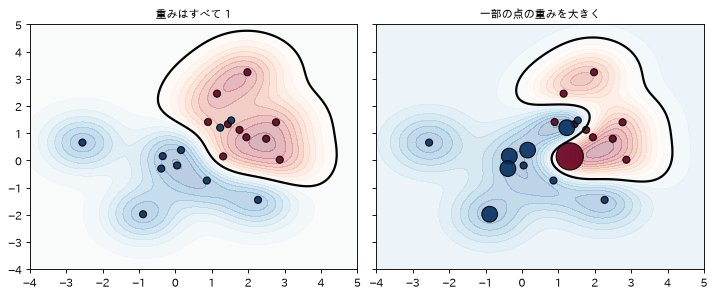

In [14]:
rng = np.random.RandomState(0)
Xw = np.r_[rng.randn(10, 2) + [1, 1], rng.randn(10, 2)]
yw = [1] * 10 + [-1] * 10
sw_const = np.ones(len(Xw))
sw_mod = np.ones(len(Xw)); sw_mod[15:] *= 5; sw_mod[9] *= 15     # 一部の点を重視する

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), sharey=True)
for ax, (title, sw) in zip(axes, [("重みはすべて 1", sw_const), ("一部の点の重みを大きく", sw_mod)]):
    m = svm.SVC(gamma=1).fit(Xw, yw, sample_weight=sw)
    xx, yy = np.meshgrid(np.linspace(-4, 5, 300), np.linspace(-4, 5, 300))
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap="RdBu_r", alpha=0.3); ax.contour(xx, yy, Z, levels=[0], colors="k", linewidths=2)
    ax.scatter(Xw[:, 0], Xw[:, 1], c=yw, s=40 * sw, cmap="RdBu_r", edgecolor="k", alpha=0.9)
    ax.set_title(title, fontsize=10); ax.grid(False)
plt.tight_layout(); plt.show()

👀 右の図では、重みの大きい点（大きな円）を正しい側に入れるように、学習した境界が大きく曲がっています。`sample_weight` は「この点は間違えてはいけない」という度合いを、点ごとに伝える手段です。

### 🏢 実務での選ばれ方: SVM による分類（`SVC` / `LinearSVC`）

- ✅ **特に選ばれる場面**: サンプルが数百〜数万で、特徴が多い・境界が複雑な分類（テキスト、スペクトル、生物のデータ、画像から作った特徴）。データが少なくても過学習しにくい。
- ❌ **選ばれない場面**: 数万件を超えるデータ（カーネルの SVM は学習が重い）。確率そのものが主な目的（スコアと確率の食い違いがある）→ ロジスティック回帰。カテゴリと数値が混ざった表形式のデータで精度を競う → 勾配ブースティング。画像・音声・文章そのもの → 深層学習。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: `make_pipeline(StandardScaler(), SVC())` + `GridSearchCV`（`C` と `gamma`）が定番の形です（2/2）。大きなデータでは `LinearSVC`、`SGDClassifier(loss="hinge")`、カーネル近似（6.7 節）+ 線形モデルに切り替えます。深層学習で作った特徴（埋め込み）の上に線形 SVM を載せる、という使い方もあります。

---
## 2. 回帰（1.4.2 Regression）

### 📖 ガイドの解説

サポートベクター分類の方法は、回帰問題を解くように拡張できます。この方法を**サポートベクター回帰（SVR）**と呼びます。

サポートベクター分類のモデルは、学習データの一部だけに依存します。モデルを作るためのコスト関数が、**マージンの外側**にある学習点を気にしないからです。同じように、SVR のモデルも学習データの一部だけに依存します。コスト関数が、**予測が目的変数に近いサンプル**を無視するからです。

SVR には 3 つの実装があります。

- `SVR`: 標準の実装
- `LinearSVR`: 線形カーネルだけを扱う、`SVR` より速い実装。liblinear による実装のため、**切片も正則化**する（`intercept_scaling` で影響を小さくできる）
- `NuSVR`: `SVR` や `LinearSVR` と少し違う定式化

分類のクラスと同じく、`fit` メソッドはベクトル `X`, `y` を受け取りますが、`y` は整数ではなく**浮動小数点数**です。

> 📚 **用語**: **ε-チューブ（イプシロン管）** — SVR の予測のまわりの、幅 ±ε の帯。この帯の中に入ったサンプルの誤差は 0 とみなして無視する（1.3 のノートで見た ε-不感損失と同じ）。帯の外や縁にあるサンプルだけがサポートベクターになる。

### 🧪 やってみよう: ガイドのコード例

In [15]:
X = [[0, 0], [2, 2]]
y = [0.5, 2.5]
regr = svm.SVR()
regr.fit(X, y)
print("predict([[1, 1]]) =", regr.predict([[1, 1]]))
assert np.allclose(regr.predict([[1, 1]]), [1.5])            # ガイドの出力と一致

predict([[1, 1]]) = [1.5]


#### 📈 学習したモデルを見る: ガイドの例「SVR using linear and non-linear kernels」

sin 曲線にノイズを加えたデータに、RBF・線形・多項式カーネルの SVR を当てはめ、学習した曲線と ε-チューブ、サポートベクターを描きます。

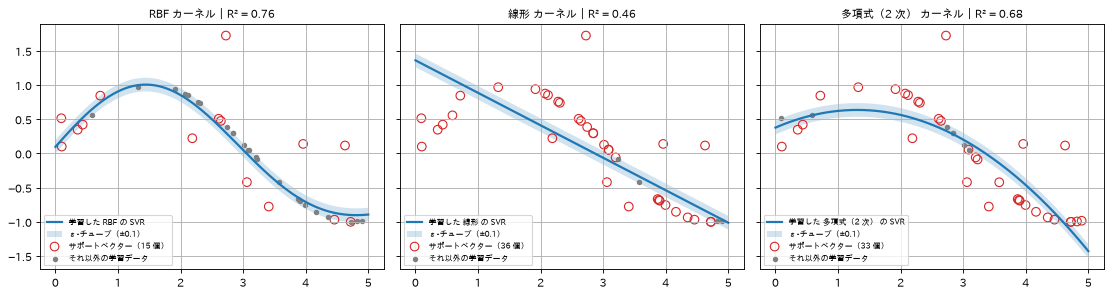

In [16]:
rng = np.random.RandomState(0)
Xs = np.sort(5 * rng.rand(40, 1), axis=0)
ys = np.sin(Xs).ravel()
ys[::5] += 3 * (0.5 - rng.rand(8))                    # 5 点に 1 点、ノイズを加える

svrs = [("RBF", svm.SVR(kernel="rbf", C=100, gamma=0.1, epsilon=0.1)),
        ("線形", svm.SVR(kernel="linear", C=100, gamma="auto")),
        ("多項式（2 次）", svm.SVR(kernel="poly", C=100, gamma="auto", degree=2, epsilon=0.1, coef0=1))]
g = np.linspace(0, 5, 200)[:, None]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, (name, m) in zip(axes, svrs):
    m.fit(Xs, ys)
    pred = m.predict(g)
    ax.plot(g, pred, lw=2, label=f"学習した {name} の SVR")
    ax.fill_between(g[:, 0], pred - m.epsilon, pred + m.epsilon, alpha=0.2, label=f"ε-チューブ（±{m.epsilon}）")
    ax.scatter(Xs[m.support_], ys[m.support_], s=60, facecolors="none", edgecolors="tab:red",
               label=f"サポートベクター（{len(m.support_)} 個）")
    other = np.setdiff1d(np.arange(len(Xs)), m.support_)
    ax.scatter(Xs[other], ys[other], s=15, c="gray", label="それ以外の学習データ")
    ax.set_title(f"{name} カーネル｜R² = {m.score(Xs, ys):.2f}", fontsize=10); ax.legend(fontsize=7, loc="lower left")
plt.tight_layout(); plt.show()

### 👀 結果の読み方

- **RBF カーネル**（左）は、sin の形に沿った曲線を学習しています。ε-チューブ（帯）の中にある灰色の点は予測に影響せず、帯の外や縁にある赤丸の点だけがサポートベクターです。
- **線形カーネル**（中）は直線しか表せず、多くの点が帯から外れるので、サポートベクターがとても多くなります。
- **多項式カーネル**（右）は、2 次曲線で大まかな形を捉えています。
- どのモデルも、ノイズを加えた点（大きく外れた点）はサポートベクターになっていますが、ε-不感損失は外れ方に比例した（二乗ではない）罰なので、曲線が大きく引っ張られることはありません。

### 🏢 実務での選ばれ方: SVR

- ✅ **特に選ばれる場面**: 中くらいのデータで、外れ値に引っ張られにくいなめらかな回帰がしたいとき。予測を軽くしたいとき（サポートベクターだけを使う）。
- ❌ **選ばれない場面**: 大きなデータ（学習が重い）。予測の不確かさが欲しい → ガウス過程（1.7 節）や分位点回帰（1.1 の 4/4）。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: カーネルリッジ回帰（1.3 節）やガウス過程と比べて選ぶことが多いです。表形式のデータの回帰では、勾配ブースティングが第一候補になりやすいです。

---
## 3. 密度推定・新規性検出（1.4.3 Density estimation, novelty detection）

### 📖 ガイドの解説

`OneClassSVM` クラスは、外れ値検出に使われる **One-Class SVM** を実装しています。説明と使い方は「2.7 新規性検出と外れ値検出」を参照してください。

> 📚 **用語**
> - **新規性検出（novelty detection）**: ふつうのデータだけで学習しておき、新しく来たデータが「これまでと違う」かどうかを判定すること。
> - **One-Class SVM**: 1 クラス分のデータだけを使い、「データが集まっている領域」の境界を学習する SVM。境界の外側を「異常」と判定する。

🕰️ **歴史（参考情報）**: One-Class SVM は、**シェルコプフ**らが 2001 年に発表した方法です（同じグループは、1.4.7 の ν-SVM も提案しています）。🏭 機械の故障検知、不正アクセスの検知、製造ラインの外観検査など、「異常なデータはほとんど集められないが、正常なデータはたくさんある」場面で使われます。

詳しくは 2.7 節で扱います。ここでは、学習した境界がどんな形になるかだけを見ておきます。

#### 📈 学習したモデルを見る: One-Class SVM の境界

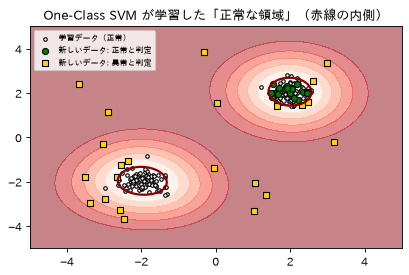

学習データのうち、境界の外とされた割合: 0.1 （nu=0.1 が目安）


In [17]:
rng = np.random.RandomState(42)
X_train = np.r_[0.3 * rng.randn(100, 2) + 2, 0.3 * rng.randn(100, 2) - 2]      # 正常なデータ（2 つの集まり）
X_new = np.r_[0.3 * rng.randn(20, 2) + 2, rng.uniform(-4, 4, (20, 2))]          # 新しいデータ（後半 20 点は異常）
oc = svm.OneClassSVM(nu=0.1, kernel="rbf", gamma=0.5).fit(X_train)

xx, yy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-5, 5, 300))
Z = oc.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap="Reds_r", alpha=0.5)
plt.contour(xx, yy, Z, levels=[0], colors="darkred", linewidths=2)
plt.scatter(X_train[:, 0], X_train[:, 1], s=10, c="white", edgecolor="k", label="学習データ（正常）")
pred_new = oc.predict(X_new)                     # +1 = 正常, -1 = 異常
plt.scatter(X_new[pred_new == 1, 0], X_new[pred_new == 1, 1], s=30, c="green", edgecolor="k", label="新しいデータ: 正常と判定")
plt.scatter(X_new[pred_new == -1, 0], X_new[pred_new == -1, 1], s=30, c="gold", edgecolor="k", marker="s", label="新しいデータ: 異常と判定")
plt.legend(fontsize=7, loc="upper left"); plt.grid(False); plt.title("One-Class SVM が学習した「正常な領域」（赤線の内側）"); plt.show()
print("学習データのうち、境界の外とされた割合:", (oc.predict(X_train) == -1).mean(), "（nu=0.1 が目安）")

👀 One-Class SVM は、正常なデータの 2 つの集まりのまわりに、それぞれ境界（濃い赤の線）を学習しました。新しいデータのうち、集まりの近くの点は正常（緑）、遠くに散らばった点は異常（黄の四角）と判定されています。学習データのうち境界の外とされた割合は、`nu=0.1` の近くになっています（`nu` の意味は 2/2 の 1.4.7 で扱います）。

### 🏢 実務での選ばれ方: One-Class SVM

- ✅ **特に選ばれる場面**: 正常なデータしか集められない異常検知（設備の監視、外観検査、不正アクセス）で、データが数千件くらいまで。
- ❌ **選ばれない場面**: 大きなデータ（学習が重い）→ `SGDOneClassSVM` + カーネル近似（1.5 節）や Isolation Forest（2.7 節）。
- 🔗 **実務でよくある組み合わせ・代わりの手法**: 実務の異常検知では、Isolation Forest、LOF（2.7 節）、オートエンコーダ（深層学習）などと比べて選ぶのが一般的です。`nu`（外れ値とみなす割合の目安）は、許容できる誤報の割合から決めます。

---
## 4. まとめ

### クラスの比較表

| クラス | 用途 | カーネル | 多クラス | サポートベクター属性 | ポイント |
|---|---|---|---|---|---|
| `SVC` | 分類 | 何でも | ovo（`decision_function_shape` で ovr 形にも） | ✅ | 正則化は `C` |
| `NuSVC` | 分類 | 何でも | ovo | ✅ | `C` の代わりに `nu`（SV と誤差の割合） |
| `LinearSVC` | 分類 | 線形のみ | ovr（または crammer_singer） | — | 大規模データで速い。切片も正則化 |
| `SVR` / `NuSVR` | 回帰 | 何でも | — | ✅ | ε-チューブの外だけがサポートベクター |
| `LinearSVR` | 回帰 | 線形のみ | — | — | 速い。切片も正則化 |
| `OneClassSVM` | 外れ値・新規性検出 | 何でも | — | ✅ | 正常なデータだけで学習（2.7 節） |

### 覚えておきたい 3 つのこと

1. **SVM はマージン最大化**。決定境界は、境界の近くにある**サポートベクター**だけで決まる。
2. **スコアと確率は別物**。確率が必要なら、非推奨の `probability=True` ではなく `CalibratedClassifierCV(SVC(), ensemble=False)` を使う。判定の基準が違うので、`predict` と食い違いうる。
3. **不均衡なデータでは `class_weight` / `sample_weight`**。全体の正解率だけでなく、少数派の再現率も確かめる。

### 🧩 ドメインモデルの視点

- `SVC` は内部で ovo の分類器を学習しますが、`decision_function_shape="ovr"`（既定）で、**外向きのインターフェースを ovr の形にそろえて**います。内部の実装と、利用者に見せる契約（出力の形）を分ける設計で、Adapter パターンに近い考え方です。
- `LinearSVC` は `support_` を持たない、確率は `CalibratedClassifierCV` で**包む**、といった具合に、同じ「SVM の分類器」でも持っている属性や機能は違います。「共通のインターフェース（`fit` / `predict` / `decision_function`）＋ クラスごとの追加の属性」という構成です。
- 確率の機能が `SVC` の引数から `CalibratedClassifierCV`（推定器を包むメタ推定器）へ移されつつあるのは、「1 つのクラスに機能を詰め込む」より「部品を組み合わせる」方向への設計の変化と見ることができます。

### ✅ 確認クイズ

**Q1.** サポートベクターとは何ですか。サポートベクター以外の学習データを少し動かすと、決定境界はどうなりますか。

<details><summary>答え</summary>

決定境界を決める、境界の近く（マージンの境界上や内側）にある学習データの点です。サポートベクター以外の点は、マージンの内側に入らない範囲で動かしても、決定境界は変わりません。
</details>

**Q2.** 5 クラスの分類で、`SVC` が内部で学習する分類器はいくつですか。`LinearSVC` ではいくつですか。

<details><summary>答え</summary>

`SVC`（one-vs-one）は 5 × 4 / 2 = 10 個、`LinearSVC`（one-vs-rest）は 5 個です。
</details>

**Q3.** scikit-learn 1.9 以降で、SVM の分類器で確率を出したいとき、どう書きますか。

<details><summary>答え</summary>

`CalibratedClassifierCV(SVC(), ensemble=False)`。`SVC(probability=True)` は 1.9 で非推奨になり、1.11 で削除される予定です。
</details>

**Q4.** 少数派のクラスを見逃したくないとき、`SVC` のどの引数を使いますか。それは何をしていますか。

<details><summary>答え</summary>

`class_weight`（例: `{少数派のラベル: 10}` や `"balanced"`）。そのクラスのサンプルの `C` を大きくして、はみ出し（誤分類）を重く罰するようにしています。
</details>

**Q5.** SVR で、予測に影響しない学習データはどれですか。

<details><summary>答え</summary>

予測とのずれが ε 以内の（ε-チューブの中にある）サンプルです。ε-不感損失では罰が 0 なので、サポートベクターになりません。
</details>

---
**前の節**: [1.3 カーネルリッジ回帰](./03_kernel_ridge.ipynb) ・ **次のノート**: [1.4（2/2）実践のコツ・カーネル・数式](./04_svm_2_practice_math.ipynb)